In [7]:
%reload_ext autoreload
%autoreload 2
%matplotlib inline

In [8]:
import torch
from nanodrz.model import DiarizeGPT, Config
from nanodrz.data import libritts_test, artificial_diarisation_sample
from nanodrz.utils import visualise_annotation, play

In [9]:
ckpt = torch.load("/home/harry/0004600.pt")
config = Config(**ckpt["config"])
model:DiarizeGPT = DiarizeGPT.from_pretrained(ckpt).cuda()

/home/harry/diarisation/.venv/lib/python3.10/site-packages/torch/nn/utils/weight_norm.py:30: UserWarning: torch.nn.utils.weight_norm is deprecated in favor of torch.nn.utils.parametrizations.weight_norm.
  warnings.warn("torch.nn.utils.weight_norm is deprecated in favor of torch.nn.utils.parametrizations.weight_norm.")


15.0650625


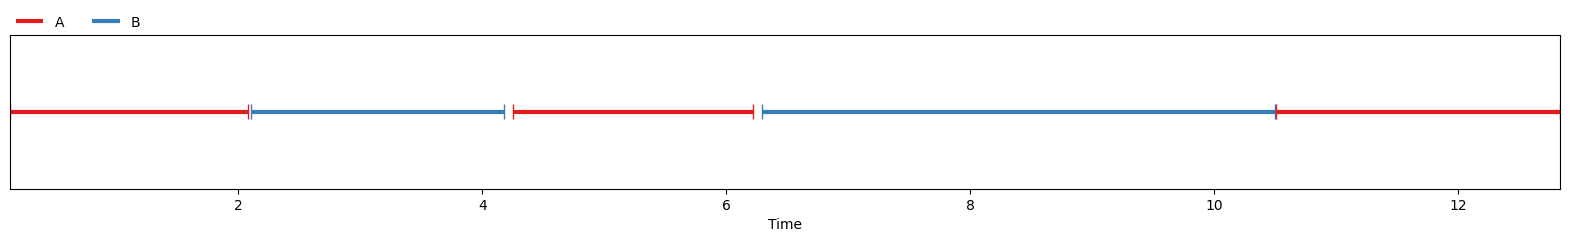

[[0.1134375, 1.9684375, 'A'],
 [2.099375, 2.080875, 'B'],
 [4.2489375, 1.9684375, 'A'],
 [6.292375, 4.2071875, 'B'],
 [10.502374999999999, 4.5626875, 'A']]

In [10]:
# Use the same parameters that the model was trained on to generate a sample
audio, labels = artificial_diarisation_sample(libritts_test(), **config.data.model_dump())
print(audio.shape[-1]/16000)
visualise_annotation(labels)
play(audio)
labels

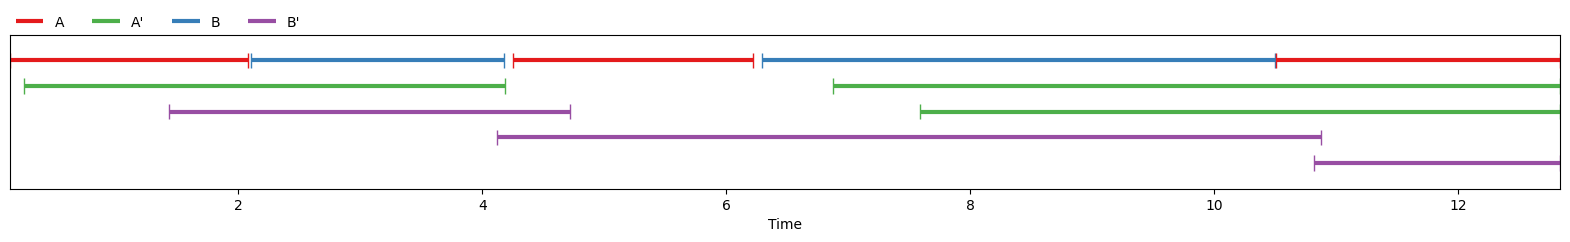

In [11]:
nlabels = model.generate(audio.cuda(), temperature=.9)
for l in nlabels:
    l[2] = l[2]+ "'"
visualise_annotation(labels+nlabels)
